# Aggregating skin (beacon) benchmarking results

In [1]:
import os

In [2]:
import numpy as np 
import scanpy as sc  
import pandas as pd

import squidpy as sq
import anndata as ad

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/software/cellgen/team361/ms83/envs/mintflow-revision/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('annd

In [3]:
base_path = '/nfs/users/nfs_m/ms83/mintflow-revision/benchmarking'

methods = ['utag', 'cellcharter', 'STAGATE', 'graphST', 'ncem']

In [4]:
all_results = []

for method in methods:
    # Load T_DC metrics
    if method == 'utag':
        tdc_filename = 'beacon_T_DC_metrics.csv'
    else:
        tdc_filename = 'metrics.csv'  # or try 'metrics.csv' if this doesn't work
    
    tdc_path = f'{base_path}/{method}/analysis/{tdc_filename}'
    
    if os.path.exists(tdc_path):
        df = pd.read_csv(tdc_path)
        df['method'] = method
        df['cluster'] = 'T_DC'
        all_results.append(df)
        print(f"Loaded {method} - T_DC: {len(df)} rows")
    else:
        print(f"WARNING: File not found - {method} - T_DC: {tdc_path}")
    
    # Load Dermis metrics
    dermis_path = f'{base_path}/{method}/analysis/beacon_Tcells_dermis_metrics.csv'
    if os.path.exists(dermis_path):
        df = pd.read_csv(dermis_path)
        df['method'] = method
        df['cluster'] = 'Dermis'
        all_results.append(df)
        print(f"Loaded {method} - Dermis: {len(df)} rows")
    else:
        print(f"WARNING: File not found - {method} - Dermis: {dermis_path}")
    
    # Load Superficial metrics
    superficial_path = f'{base_path}/{method}/analysis/beacon_Tcells_superficial_metrics.csv'
    if os.path.exists(superficial_path):
        df = pd.read_csv(superficial_path)
        df['method'] = method
        df['cluster'] = 'Superficial'
        all_results.append(df)
        print(f"Loaded {method} - Superficial: {len(df)} rows")
    else:
        print(f"WARNING: File not found - {method} - Superficial: {superficial_path}")

# Combine all results
combined_results = pd.concat(all_results, ignore_index=True)

print(f"\nTotal combined results: {len(combined_results)} rows")
print(f"\nMethods: {combined_results['method'].unique()}")
print(f"Clusters: {combined_results['cluster'].unique()}")
print(f"\nData per method and cluster:")
print(combined_results.groupby(['method', 'cluster']).size())
print(f"\nColumns: {combined_results.columns.tolist()}")

Loaded utag - T_DC: 64 rows
Loaded utag - Dermis: 64 rows
Loaded utag - Superficial: 64 rows
Loaded cellcharter - T_DC: 64 rows
Loaded cellcharter - Dermis: 64 rows
Loaded cellcharter - Superficial: 64 rows
Loaded STAGATE - T_DC: 64 rows
Loaded STAGATE - Dermis: 64 rows
Loaded STAGATE - Superficial: 64 rows
Loaded graphST - T_DC: 64 rows
Loaded graphST - Dermis: 64 rows
Loaded graphST - Superficial: 64 rows
Loaded ncem - T_DC: 64 rows
Loaded ncem - Dermis: 64 rows
Loaded ncem - Superficial: 64 rows

Total combined results: 960 rows

Methods: ['utag' 'cellcharter' 'STAGATE' 'graphST' 'ncem']
Clusters: ['T_DC' 'Dermis' 'Superficial']

Data per method and cluster:
method       cluster    
STAGATE      Dermis         64
             Superficial    64
             T_DC           64
cellcharter  Dermis         64
             Superficial    64
             T_DC           64
graphST      Dermis         64
             Superficial    64
             T_DC           64
ncem         Dermis       

In [5]:
combined_results

,Unnamed: 0,recall,precision,f1,split_entropy,best_cluster,n_clusters_with_niche,resolution,k_neighbors,method,cluster
0,0,0.180275,0.367073,0.241798,4.286608,14,213,0.3,3,utag,T_DC
1,1,0.231568,0.230453,0.231009,3.583308,4,65,0.3,4,utag,T_DC
2,2,0.346208,0.327072,0.336368,3.188985,5,32,0.3,5,utag,T_DC
3,3,0.308640,0.338806,0.323020,3.115672,8,27,0.3,6,utag,T_DC
4,4,0.345856,0.189647,0.244968,3.069921,0,24,0.3,7,utag,T_DC
...,...,...,...,...,...,...,...,...,...,...,...
955,59,0.279844,0.482476,0.354229,4.268117,0,44,1.0,6,ncem,Superficial
956,60,0.416522,0.465217,0.439525,3.782065,0,40,1.0,7,ncem,Superficial
957,61,0.278979,0.465368,0.348837,3.953533,1,36,1.0,8,ncem,Superficial
958,62,0.399221,0.489396,0.439733,3.718435,0,34,1.0,9,ncem,Superficial


In [6]:
# Save combined results
combined_results.to_csv('all_methods_combined_results.csv', index=False)
print("\nSaved combined results to 'all_methods_beacon_combined_results.csv'")


Saved combined results to 'all_methods_beacon_combined_results_noscVIVA.csv'


In [7]:
# Calculate average metrics across the 3 clusters for each method and parameter combination
avg_results = combined_results.groupby(['method', 'resolution', 'k_neighbors']).agg({
    'recall': 'mean',
    'precision': 'mean',
    'f1': 'mean',
    'split_entropy': 'mean'
}).reset_index()

print(f"Averaged results: {len(avg_results)} rows")
print(f"Methods: {avg_results['method'].unique()}")

Averaged results: 320 rows
Methods: ['STAGATE' 'cellcharter' 'graphST' 'ncem' 'utag']


/tmp/ipykernel_670763/1373903083.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df_entropy, x='Method', y='Value', ax=axes[1], palette='Set2')


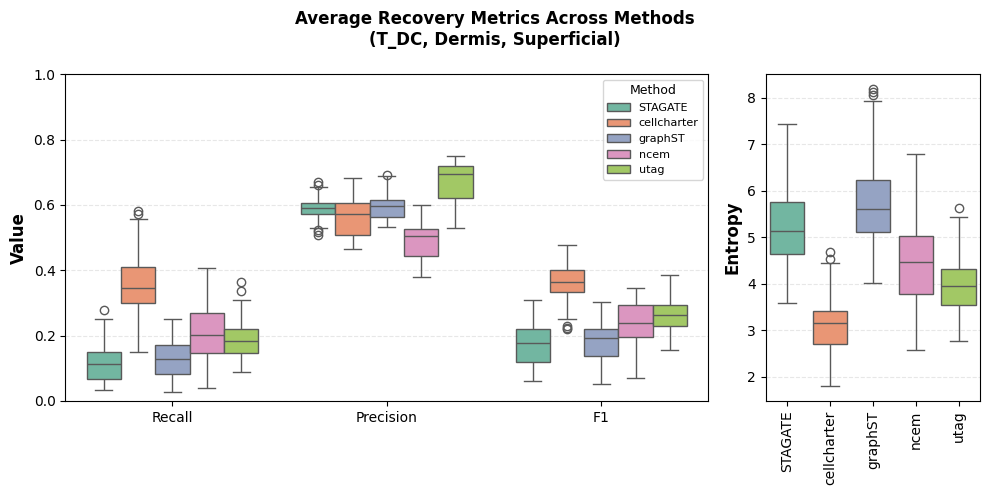

In [8]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [3, 1]})

# Left panel: Recall, Precision, F1
metrics_01 = ['recall', 'precision', 'f1']
plot_data_01 = []

for method in avg_results['method'].unique():
    method_data = avg_results[avg_results['method'] == method]
    for metric in metrics_01:
        for val in method_data[metric]:
            plot_data_01.append({
                'Method': method,
                'Metric': metric.replace('_', ' ').title(),
                'Value': val
            })

plot_df_01 = pd.DataFrame(plot_data_01)

# Create grouped boxplot
sns.boxplot(data=plot_df_01, x='Metric', y='Value', hue='Method', ax=axes[0], palette='Set2')
# Optional: add strip plot for individual points
# sns.stripplot(data=plot_df_01, x='Metric', y='Value', hue='Method', ax=axes[0], 
#              color='black', alpha=0.2, size=1, dodge=True, legend=False)

axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[0].set_xlabel('', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend(title='Method', fontsize=8, title_fontsize=9)

# Right panel: Split Entropy
plot_data_entropy = []
for method in avg_results['method'].unique():
    method_data = avg_results[avg_results['method'] == method]
    for val in method_data['split_entropy']:
        plot_data_entropy.append({
            'Method': method,
            'Value': val
        })

plot_df_entropy = pd.DataFrame(plot_data_entropy)

sns.boxplot(data=plot_df_entropy, x='Method', y='Value', ax=axes[1], palette='Set2')
# Optional: add strip plot
# sns.stripplot(data=plot_df_entropy, x='Method', y='Value', ax=axes[1], 
#              color='black', alpha=0.2, size=1)

axes[1].set_ylabel('Entropy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Average Recovery Metrics Across Methods\n(T_DC, Dermis, Superficial)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('methods_comparison_boxplots_beacon.pdf', dpi=300, bbox_inches='tight')
plt.show()